
Objetivo da etapa:
- adicionar modelos não lineares e ensembles: **Decision Tree**, **Random Forest** e **Gradient Boosting**;
- construir, treinar e avaliar uma **MLP em PyTorch**;
- comparar todos os modelos via **MLflow**;
- analisar o trade-off entre **falso positivo** e **falso negativo** por meio de uma simulação de custo;
- registrar modelos, métricas e artefatos no MLflow.



In [28]:
import copy
import tempfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from mlflow.tracking import MlflowClient
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from torch.utils.data import DataLoader, TensorDataset


 Configurações gerais

As premissas de custo são hipóteses para demonstrar o trade-off de negócio:
- **FN**: cliente que iria cancelar e não foi detectado;
- **FP**: cliente que recebeu ação de retenção sem necessidade;
- **TP**: cliente com churn corretamente identificado e potencialmente retido;
- **TN**: cliente sem churn corretamente ignorado.



In [29]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20

BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 1e-3
THRESHOLD_DEFAULT = 0.50

EXPERIMENT_NAME = "churn-model-comparison"

# Premissas de custo para análise FP vs FN
CUSTO_FN = 500    # Perder um cliente que iria cancelar
CUSTO_FP = 50     # Oferecer retenção para cliente que não cancelaria
CUSTO_TP = -450   # Churn evitado: salvou 500, gastou 50
CUSTO_TN = 0      # Sem custo

mlflow.set_experiment(EXPERIMENT_NAME)

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Experimento MLflow:", EXPERIMENT_NAME)


Experimento MLflow: churn-model-comparison


In [30]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    NOTEBOOKS_DIR = CURRENT_DIR
else:
    NOTEBOOKS_DIR = CURRENT_DIR / "notebooks"

MLFLOW_DB = NOTEBOOKS_DIR / "mlflow.db"
MLRUNS_DIR = NOTEBOOKS_DIR / "mlruns"

MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
mlflow.set_experiment("churn-model-comparison")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow artifacts dir:", MLRUNS_DIR)

MLflow tracking URI: sqlite:///c:/Users/fequi/OneDrive/Ambiente de Trabalho/Repos/tech-challenge/Tech-Challenge-Fase1/notebooks/mlflow.db
MLflow artifacts dir: c:\Users\fequi\OneDrive\Ambiente de Trabalho\Repos\tech-challenge\Tech-Challenge-Fase1\notebooks\mlruns


Carregamento dos dados



In [31]:
DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset carregado de: {DATA_PATH.resolve()}")
print(df.shape)

df.head()


Dataset carregado de: C:\Users\fequi\OneDrive\Ambiente de Trabalho\Repos\tech-challenge\Tech-Challenge-Fase1\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Preparação inicial dos dados

Mantemos a mesma preparação usada no baseline:
- conversão de `TotalCharges` para numérico;
- criação da target binária;
- remoção de `customerID`, por ser identificador único.


In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["target"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn", "target", "customerID"], errors="ignore")
y = df["target"]

print("Distribuição da target:")
display(y.value_counts(normalize=True).rename(index={0: "Sem churn", 1: "Com churn"}))


Distribuição da target:


target
Sem churn    0.73463
Com churn    0.26537
Name: proportion, dtype: float64

Split treino/teste estratificado

Usamos `stratify=y` para manter a proporção de churn no treino e no teste.


In [33]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Treino:", X_train_full.shape)
print("Teste:", X_test.shape)

print("\nDistribuição target treino:")
display(y_train_full.value_counts(normalize=True))

print("\nDistribuição target teste:")
display(y_test.value_counts(normalize=True))


Treino: (5634, 19)
Teste: (1409, 19)

Distribuição target treino:


target
0    0.734647
1    0.265353
Name: proportion, dtype: float64


Distribuição target teste:


target
0    0.734564
1    0.265436
Name: proportion, dtype: float64

Pré-processamento

O pré-processamento replica a lógica do baseline:
- imputação pela mediana para numéricas;
- padronização das numéricas;
- imputação pela moda para categóricas;
- one-hot encoding para categóricas.

Isso garante comparação justa entre modelos.


In [34]:
numeric_cols = X_train_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_full.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

print("Features numéricas:", numeric_cols)
print("Features categóricas:", categorical_cols)


Features numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']




Métricas do projeto:
- ROC-AUC;
- PR-AUC;
- F1;
- Precision;
- Recall.

Também calculamos o custo total para diferentes thresholds, com base nas premissas de FP, FN, TP e TN.


In [35]:
def evaluate_model(y_true, y_pred, y_proba):
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }


def calculate_cost_by_threshold(
    y_true,
    y_proba,
    thresholds=None,
    custo_fn=CUSTO_FN,
    custo_fp=CUSTO_FP,
    custo_tp=CUSTO_TP,
    custo_tn=CUSTO_TN,
):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        custo_total = (
            fn * custo_fn
            + fp * custo_fp
            + tp * custo_tp
            + tn * custo_tn
        )

        rows.append(
            {
                "threshold": threshold,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "custo_total": custo_total,
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )

    costs_df = pd.DataFrame(rows)
    best_row = costs_df.loc[costs_df["custo_total"].idxmin()]

    return costs_df, best_row


def ensure_dense(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)



Cada modelo terá artefatos registrados no MLflow:
- curva ROC;
- curva Precision-Recall;
- curva de custo por threshold;
- matrizes de confusão no threshold padrão e no threshold ótimo por custo;
- tabela de custo por threshold.


In [36]:
def save_cost_curve(costs_df, best_threshold, output_path):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(
        costs_df["threshold"],
        costs_df["custo_total"],
        marker="o",
        linewidth=2,
        label="Custo Total",
    )
    ax1.axvline(
        x=best_threshold,
        linestyle="--",
        label=f"Threshold ótimo: {best_threshold:.2f}",
    )
    ax1.set_xlabel("Threshold")
    ax1.set_ylabel("Custo Total")
    ax1.grid(alpha=0.3)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(
        costs_df["threshold"],
        costs_df["recall"],
        linestyle="--",
        linewidth=2,
        label="Recall",
    )
    ax2.plot(
        costs_df["threshold"],
        costs_df["precision"],
        linestyle="--",
        linewidth=2,
        label="Precision",
    )
    ax2.set_ylabel("Score")
    ax2.legend(loc="upper right")

    plt.title("Trade-off de Custo: Threshold vs Custo Total")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


def save_confusion_matrices(y_true, y_pred_default, y_pred_optimal, best_threshold, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred_default,
        display_labels=["Sem Churn", "Com Churn"],
        cmap="Blues",
        ax=axes[0],
    )
    axes[0].set_title("Threshold = 0.50")

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred_optimal,
        display_labels=["Sem Churn", "Com Churn"],
        cmap="Blues",
        ax=axes[1],
    )
    axes[1].set_title(f"Threshold ótimo por custo = {best_threshold:.2f}")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


def save_roc_curve(y_true, y_proba, model_name, output_path):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} | AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


def save_pr_curve(y_true, y_proba, model_name, output_path):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"{model_name} | PR-AUC={pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


Registro da análise de custo no MLflow



In [37]:
def log_cost_analysis_artifacts(model_name, y_true, y_pred_default, y_proba):
    costs_df, best_row = calculate_cost_by_threshold(y_true, y_proba)

    best_threshold = float(best_row["threshold"])
    y_pred_optimal = (y_proba >= best_threshold).astype(int)

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)

        costs_path = tmp_dir / f"{model_name}_cost_by_threshold.csv"
        cost_curve_path = tmp_dir / f"{model_name}_cost_curve.png"
        cm_path = tmp_dir / f"{model_name}_confusion_matrices.png"
        roc_path = tmp_dir / f"{model_name}_roc_curve.png"
        pr_path = tmp_dir / f"{model_name}_pr_curve.png"

        costs_df.to_csv(costs_path, index=False)

        save_cost_curve(costs_df, best_threshold, cost_curve_path)
        save_confusion_matrices(
            y_true,
            y_pred_default,
            y_pred_optimal,
            best_threshold,
            cm_path,
        )
        save_roc_curve(y_true, y_proba, model_name, roc_path)
        save_pr_curve(y_true, y_proba, model_name, pr_path)

        mlflow.log_artifact(str(costs_path), artifact_path="cost_analysis")
        mlflow.log_artifact(str(cost_curve_path), artifact_path="plots")
        mlflow.log_artifact(str(cm_path), artifact_path="plots")
        mlflow.log_artifact(str(roc_path), artifact_path="plots")
        mlflow.log_artifact(str(pr_path), artifact_path="plots")

    mlflow.log_metric("best_cost_threshold", best_threshold)
    mlflow.log_metric("min_total_cost", float(best_row["custo_total"]))
    mlflow.log_metric("recall_at_best_cost_threshold", float(best_row["recall"]))
    mlflow.log_metric("precision_at_best_cost_threshold", float(best_row["precision"]))
    mlflow.log_metric("f1_at_best_cost_threshold", float(best_row["f1"]))

    return costs_df, best_row


Modelos não lineares e ensembles

Eles complementam o baseline linear e permitem comparar a MLP com modelos fortes para dados tabulares.


In [38]:
tree_models = {
    "decision_tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

tree_results = {}
model_probabilities = {}


In [39]:
for model_name, estimator in tree_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", estimator),
        ]
    )

    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train_full, y_train_full)

        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        metrics = evaluate_model(y_test, y_pred, y_proba)
        tree_results[model_name] = metrics
        model_probabilities[model_name] = y_proba

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("model_family", "tree_or_ensemble")
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("threshold_default", THRESHOLD_DEFAULT)

        model_params = estimator.get_params()
        for param_name, param_value in model_params.items():
            if isinstance(param_value, (str, int, float, bool, type(None))):
                mlflow.log_param(param_name, param_value)

        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(metric_name, metric_value)

        log_cost_analysis_artifacts(
            model_name=model_name,
            y_true=y_test,
            y_pred_default=y_pred,
            y_proba=y_proba,
        )

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path="model",
        )

print("Modelos não lineares treinados e registrados no MLflow.")
display(pd.DataFrame(tree_results).T.sort_values(by="roc_auc", ascending=False))


2026/04/28 22:03:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 22:03:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/28 22:03:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 22:03:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelos não lineares treinados e registrados no MLflow.


,roc_auc,pr_auc,f1,precision,recall
gradient_boosting,0.845464,0.664635,0.583587,0.676056,0.513369
random_forest,0.841607,0.655631,0.587519,0.681979,0.516043
decision_tree,0.830278,0.622324,0.598870,0.634731,0.566845


Preparação dos dados para MLP

A MLP usa o mesmo pré-processamento, mas cria também um conjunto de validação para o **early stopping**.


In [40]:
X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

preprocessor_mlp = clone(preprocessor)

X_train_mlp_transformed = preprocessor_mlp.fit_transform(X_train_mlp)
X_val_mlp_transformed = preprocessor_mlp.transform(X_val_mlp)
X_test_mlp_transformed = preprocessor_mlp.transform(X_test)

X_train_mlp_transformed = ensure_dense(X_train_mlp_transformed)
X_val_mlp_transformed = ensure_dense(X_val_mlp_transformed)
X_test_mlp_transformed = ensure_dense(X_test_mlp_transformed)

X_train_tensor = torch.tensor(X_train_mlp_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_mlp.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_mlp_transformed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_mlp.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_mlp_transformed, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print("Input dimension MLP:", X_train_tensor.shape[1])


Input dimension MLP: 45


Arquitetura da MLP

Decisões:
- **3 camadas ocultas (128 → 64 → 32)**: arquitetura compacta para dataset tabular com cerca de 7k registros;
- **ReLU**: ativação padrão, eficiente e estável;
- **BatchNorm**: estabiliza o treinamento;
- **Dropout (0.3)**: reduz risco de overfitting;
- **Saída linear + `BCEWithLogitsLoss`**: mais estável numericamente do que aplicar `Sigmoid` antes da loss. Na avaliação, usamos `torch.sigmoid()` para converter logits em probabilidade de churn.


In [41]:
class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


mlp_model = ChurnMLP(input_dim=X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)

mlp_model


ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Treinamento da MLP com batching e early stopping

In [42]:
best_val_loss = float("inf")
best_state_dict = None
early_stop_counter = 0

history = []

for epoch in range(1, EPOCHS + 1):
    mlp_model.train()
    train_losses = []

    for xb, yb in train_loader:
        logits = mlp_model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))

    mlp_model.eval()
    with torch.no_grad():
        val_logits = mlp_model(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor).item()

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        }
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(mlp_model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f}"
        )

    if early_stop_counter >= PATIENCE:
        print(f"Early stopping acionado na época {epoch}.")
        break

if best_state_dict is not None:
    mlp_model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history)
display(history_df.tail())


Epoch 001 | train_loss=0.4907 | val_loss=0.4304
Epoch 010 | train_loss=0.4157 | val_loss=0.4176
Early stopping acionado na época 17.


,epoch,train_loss,val_loss
12,13,0.409546,0.418981
13,14,0.403306,0.419930
14,15,0.405286,0.418402
15,16,0.398863,0.423234
16,17,0.400929,0.423331


Avaliação da MLP no threshold padrão

In [43]:
mlp_model.eval()

with torch.no_grad():
    test_logits = mlp_model(X_test_tensor)
    y_test_proba_mlp = torch.sigmoid(test_logits).numpy().flatten()

y_test_pred_mlp = (y_test_proba_mlp >= THRESHOLD_DEFAULT).astype(int)

metrics_mlp = evaluate_model(
    y_true=y_test,
    y_pred=y_test_pred_mlp,
    y_proba=y_test_proba_mlp,
)

model_probabilities["mlp"] = y_test_proba_mlp

print("Métricas MLP — threshold padrão 0.50")
display(pd.DataFrame(metrics_mlp, index=["mlp"]))


Métricas MLP — threshold padrão 0.50


,roc_auc,pr_auc,f1,precision,recall
mlp,0.839252,0.631276,0.59021,0.618768,0.564171


Registro da MLP, artefatos e análise de custo no MLflow

In [44]:
with mlflow.start_run(run_name="mlp"):
    mlflow.log_param("model_name", "mlp")
    mlflow.log_param("model_family", "pytorch_mlp")
    mlflow.log_param("architecture", "128-64-32")
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("batch_norm", True)
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("loss_function", "BCEWithLogitsLoss")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("max_epochs", EPOCHS)
    mlflow.log_param("actual_epochs", len(history_df))
    mlflow.log_param("patience", PATIENCE)
    mlflow.log_param("threshold_default", THRESHOLD_DEFAULT)
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric_name, metric_value in metrics_mlp.items():
        mlflow.log_metric(metric_name, metric_value)

    costs_df_mlp, best_row_mlp = log_cost_analysis_artifacts(
        model_name="mlp",
        y_true=y_test,
        y_pred_default=y_test_pred_mlp,
        y_proba=y_test_proba_mlp,
    )

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)

        history_path = tmp_dir / "mlp_training_history.csv"
        history_plot_path = tmp_dir / "mlp_training_history.png"
        preprocessor_path = tmp_dir / "mlp_preprocessor.joblib"

        history_df.to_csv(history_path, index=False)

        plt.figure(figsize=(8, 5))
        plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
        plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("MLP Training History")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(history_plot_path, dpi=150)
        plt.close()

        joblib.dump(preprocessor_mlp, preprocessor_path)

        mlflow.log_artifact(str(history_path), artifact_path="training")
        mlflow.log_artifact(str(history_plot_path), artifact_path="plots")
        mlflow.log_artifact(str(preprocessor_path), artifact_path="preprocessing")

    mlflow.pytorch.log_model(
        pytorch_model=mlp_model,
        artifact_path="model",
    )

print("MLP registrada no MLflow com modelo, histórico, pré-processador e artefatos.")


2026/04/28 22:03:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 22:03:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


MLP registrada no MLflow com modelo, histórico, pré-processador e artefatos.


Comparação 

Busca os runs já registrados, incluindo `dummy` e `logistic` do notebook de baseline e os modelos desta etapa.

Se `dummy` e `logistic` não aparecerem, rode primeiro o notebook `baselines.ipynb` no mesmo diretório de tracking do MLflow.


In [45]:
client = MlflowClient()
experiments = client.search_experiments()

experiment_ids = [
    exp.experiment_id
    for exp in experiments
    if exp.lifecycle_stage == "active"
]

runs = mlflow.search_runs(
    experiment_ids=experiment_ids,
    order_by=["start_time DESC"],
)

expected_models = [
    "dummy",
    "logistic",
    "decision_tree",
    "random_forest",
    "gradient_boosting",
    "mlp",
]

comparison_cols = [
    "tags.mlflow.runName",
    "metrics.roc_auc",
    "metrics.pr_auc",
    "metrics.f1",
    "metrics.precision",
    "metrics.recall",
    "metrics.best_cost_threshold",
    "metrics.min_total_cost",
    "metrics.recall_at_best_cost_threshold",
    "metrics.precision_at_best_cost_threshold",
    "metrics.f1_at_best_cost_threshold",
    "run_id",
]

available_cols = [col for col in comparison_cols if col in runs.columns]

comparison_df = runs[available_cols].copy()

comparison_df = comparison_df.rename(
    columns={
        "tags.mlflow.runName": "model",
        "metrics.roc_auc": "roc_auc",
        "metrics.pr_auc": "pr_auc",
        "metrics.f1": "f1",
        "metrics.precision": "precision",
        "metrics.recall": "recall",
        "metrics.best_cost_threshold": "best_cost_threshold",
        "metrics.min_total_cost": "min_total_cost",
        "metrics.recall_at_best_cost_threshold": "recall_best_cost",
        "metrics.precision_at_best_cost_threshold": "precision_best_cost",
        "metrics.f1_at_best_cost_threshold": "f1_best_cost",
    }
)

comparison_df = comparison_df[comparison_df["model"].isin(expected_models)]
comparison_df = comparison_df.drop_duplicates(subset=["model"], keep="first")
comparison_df = comparison_df.set_index("model")
comparison_df = comparison_df.sort_values(by="roc_auc", ascending=False)

print("=== Tabela comparativa de modelos ===")
display(comparison_df)


=== Tabela comparativa de modelos ===


,roc_auc,pr_auc,f1,precision,recall,best_cost_threshold,min_total_cost,recall_best_cost,precision_best_cost,f1_best_cost,run_id
model,,,,,,,,,,,
gradient_boosting,0.845464,0.664635,0.583587,0.676056,0.513369,0.1,-122450.0,0.943850,0.405281,0.567068,609ee31152b9491d8fb612336b9aa9f6
logistic,0.841874,0.633388,0.604046,0.657233,0.558824,NaN,NaN,NaN,NaN,NaN,df59b02802ab4eea8e3cba7adb29e631
random_forest,0.841607,0.655631,0.587519,0.681979,0.516043,0.1,-123800.0,0.954545,0.386364,0.550077,dd51c1a196974b33b6bdafda85d34d64
mlp,0.839252,0.631276,0.590210,0.618768,0.564171,0.1,-125800.0,0.957219,0.396018,0.560250,db0e236cf93f44ea9b327d2a68d43704
decision_tree,0.830278,0.622324,0.598870,0.634731,0.566845,0.1,-125600.0,0.970588,0.360119,0.525326,65902d6fec6c40098f36bee26aaba8ea
dummy,0.500000,0.265436,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,4ccc589962eb4e5fab9d012e16bd045b


Carregar probabilidades dos modelos lineares do MLflow

Para incluir `dummy` e `logistic` nos gráficos comparativos, carregamos os modelos registrados no notebook de baseline.


In [46]:
latest_runs = comparison_df.reset_index()

for baseline_model in ["dummy", "logistic"]:
    if baseline_model not in model_probabilities and baseline_model in latest_runs["model"].values:
        run_id = latest_runs.loc[
            latest_runs["model"] == baseline_model,
            "run_id",
        ].iloc[0]

        model_uri = f"runs:/{run_id}/model"

        try:
            loaded_model = mlflow.sklearn.load_model(model_uri)
            y_proba_baseline = loaded_model.predict_proba(X_test)[:, 1]
            model_probabilities[baseline_model] = y_proba_baseline
            print(f"Modelo carregado do MLflow para gráficos: {baseline_model}")
        except Exception as error:
            print(f"Não foi possível carregar {baseline_model}: {error}")


Modelo carregado do MLflow para gráficos: dummy


Modelo carregado do MLflow para gráficos: logistic


 Gráfico ROC comparativo

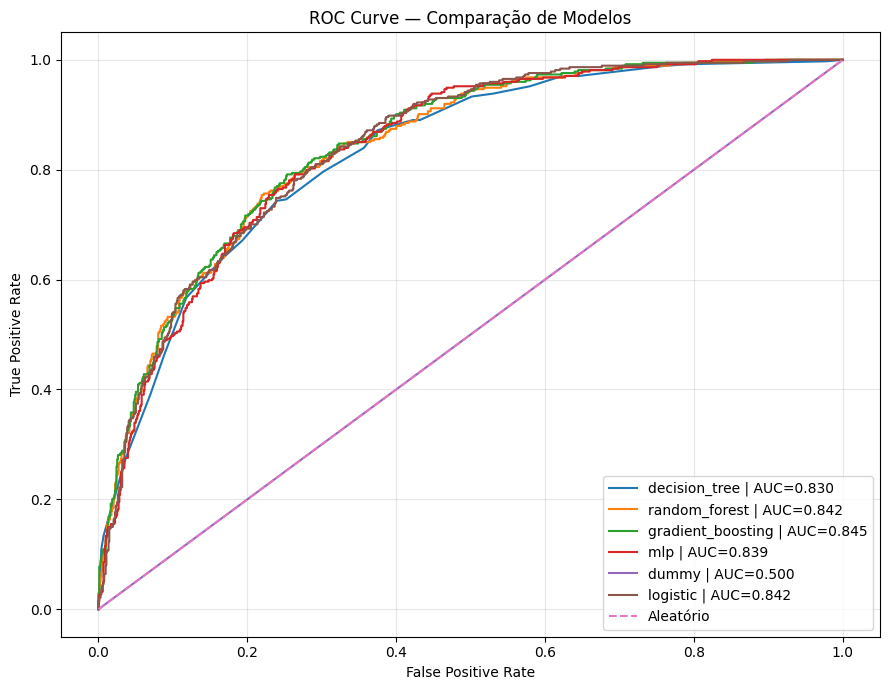

In [47]:
plt.figure(figsize=(9, 7))

for model_name, y_proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} | AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Comparação de Modelos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Gráfico de comparação das métricas principais

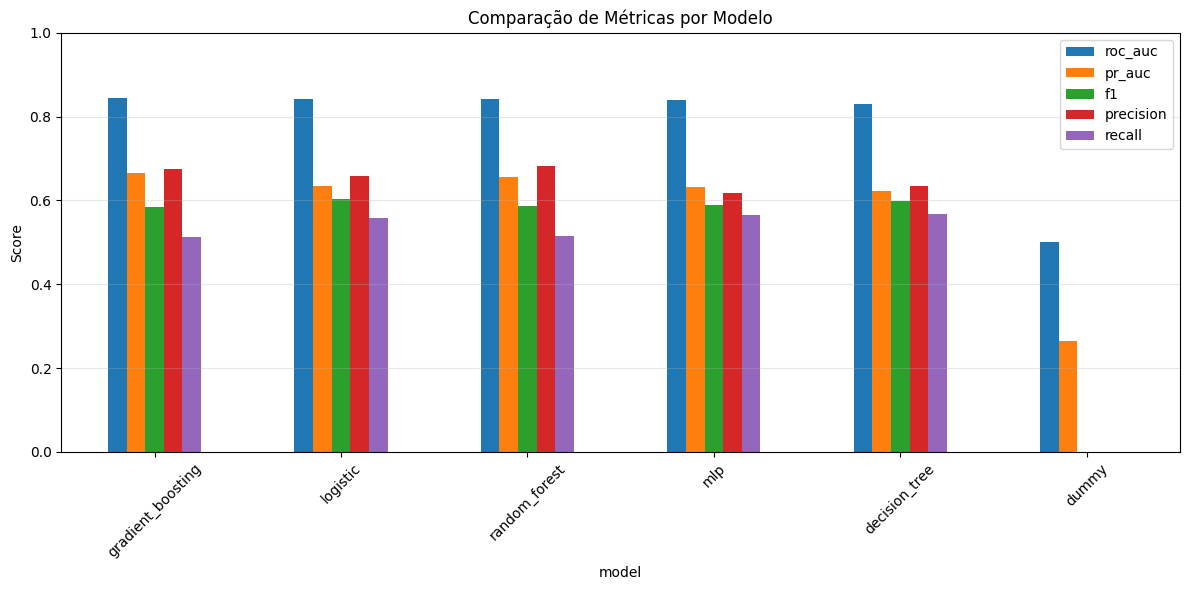

In [48]:
metric_cols = ["roc_auc", "pr_auc", "f1", "precision", "recall"]
available_metric_cols = [col for col in metric_cols if col in comparison_df.columns]

comparison_df[available_metric_cols].plot(
    kind="bar",
    figsize=(12, 6),
    rot=45,
)

plt.title("Comparação de Métricas por Modelo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


 Análise de custo da MLP

Aqui avaliamos se o threshold padrão de 0.50 é realmente adequado do ponto de vista de negócio.


In [49]:
print("=== PREMISSAS DE CUSTO ===")
print(f"Falso Negativo — churn não detectado: R${CUSTO_FN}")
print(f"Falso Positivo — oferta desnecessária: R${CUSTO_FP}")
print(f"Verdadeiro Positivo — churn evitado: R${CUSTO_TP}")
print(f"Verdadeiro Negativo — correto: R${CUSTO_TN}")

best_threshold_mlp = float(best_row_mlp["threshold"])

print(f"\nThreshold ótimo por custo para MLP: {best_threshold_mlp:.2f}")
print(f"Custo mínimo estimado: R${best_row_mlp['custo_total']:.2f}")
print(f"Recall no threshold ótimo: {best_row_mlp['recall']:.4f}")
print(f"Precision no threshold ótimo: {best_row_mlp['precision']:.4f}")

display(costs_df_mlp)


=== PREMISSAS DE CUSTO ===
Falso Negativo — churn não detectado: R$500
Falso Positivo — oferta desnecessária: R$50
Verdadeiro Positivo — churn evitado: R$-450
Verdadeiro Negativo — correto: R$0

Threshold ótimo por custo para MLP: 0.10
Custo mínimo estimado: R$-125800.00
Recall no threshold ótimo: 0.9572
Precision no threshold ótimo: 0.3960


,threshold,TP,FP,FN,TN,custo_total,recall,precision,f1
0,0.10,358,546,16,489,-125800,0.957219,0.396018,0.560250
1,0.15,351,465,23,570,-123200,0.938503,0.430147,0.589916
2,0.20,323,378,51,657,-100950,0.863636,0.460770,0.600930
3,0.25,310,324,64,711,-91300,0.828877,0.488959,0.615079
4,0.30,292,266,82,769,-77100,0.780749,0.523297,0.626609
5,0.35,273,226,101,809,-61050,0.729947,0.547094,0.625430
6,0.40,253,187,121,848,-44000,0.676471,0.575000,0.621622
7,0.45,230,164,144,871,-23300,0.614973,0.583756,0.598958
8,0.50,211,130,163,905,-6950,0.564171,0.618768,0.590210
9,0.55,184,95,190,940,16950,0.491979,0.659498,0.563553


 Matriz de confusão: threshold padrão vs threshold ótimo

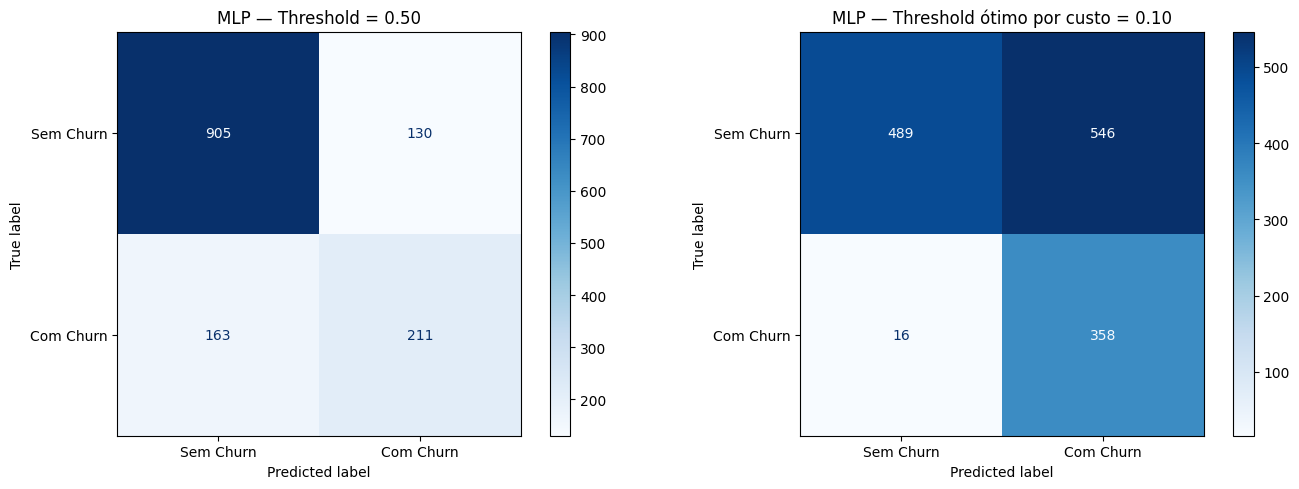

In [50]:
y_pred_mlp_optimal = (y_test_proba_mlp >= best_threshold_mlp).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_mlp,
    display_labels=["Sem Churn", "Com Churn"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("MLP — Threshold = 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp_optimal,
    display_labels=["Sem Churn", "Com Churn"],
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title(f"MLP — Threshold ótimo por custo = {best_threshold_mlp:.2f}")

plt.tight_layout()
plt.show()


Registro dos artefatos comparativos finais no MLflow

Esta etapa cria um run consolidado no MLflow com os principais artefatos da comparação entre modelos.

O objetivo não é treinar um novo modelo, mas centralizar os resultados finais da Etapa 2 em um único run de resumo, incluindo:

- tabela comparativa de métricas;
- curva ROC comparativa;
- curva Precision-Recall comparativa;
- gráfico de métricas por modelo;
- análise de custo da MLP por threshold;
- matriz de confusão da MLP no threshold padrão e no threshold ótimo por custo.

Esse run facilita a navegação no MLflow e ajuda a demonstrar que a etapa entregou comparação de modelos, análise de trade-off e artefatos rastreáveis.

In [51]:
# ============================================================
# Registro dos artefatos comparativos finais no MLflow
# ============================================================

metric_cols = ["roc_auc", "pr_auc", "f1", "precision", "recall"]
available_metric_cols = [
    col for col in metric_cols
    if col in comparison_df.columns
]

comparison_export_df = comparison_df.copy()

if "roc_auc" in comparison_export_df.columns:
    comparison_export_df = comparison_export_df.sort_values(
        by="roc_auc",
        ascending=False,
    )

best_model_by_roc_auc = None
best_model_by_pr_auc = None
best_model_by_f1 = None

if "roc_auc" in comparison_export_df.columns and comparison_export_df["roc_auc"].notna().any():
    best_model_by_roc_auc = comparison_export_df["roc_auc"].idxmax()

if "pr_auc" in comparison_export_df.columns and comparison_export_df["pr_auc"].notna().any():
    best_model_by_pr_auc = comparison_export_df["pr_auc"].idxmax()

if "f1" in comparison_export_df.columns and comparison_export_df["f1"].notna().any():
    best_model_by_f1 = comparison_export_df["f1"].idxmax()


with mlflow.start_run(run_name="model_comparison_summary") as run:
    mlflow.log_param("run_type", "consolidated_model_comparison")
    mlflow.log_param("experiment_name", EXPERIMENT_NAME)
    mlflow.log_param("models_compared", ", ".join(comparison_export_df.index.tolist()))
    mlflow.log_param("metrics_compared", ", ".join(available_metric_cols))

    mlflow.log_param("cost_fn", CUSTO_FN)
    mlflow.log_param("cost_fp", CUSTO_FP)
    mlflow.log_param("cost_tp", CUSTO_TP)
    mlflow.log_param("cost_tn", CUSTO_TN)

    if best_model_by_roc_auc is not None:
        mlflow.log_param("best_model_by_roc_auc", best_model_by_roc_auc)
        mlflow.log_metric(
            "best_roc_auc",
            float(comparison_export_df.loc[best_model_by_roc_auc, "roc_auc"]),
        )

    if best_model_by_pr_auc is not None:
        mlflow.log_param("best_model_by_pr_auc", best_model_by_pr_auc)
        mlflow.log_metric(
            "best_pr_auc",
            float(comparison_export_df.loc[best_model_by_pr_auc, "pr_auc"]),
        )

    if best_model_by_f1 is not None:
        mlflow.log_param("best_model_by_f1", best_model_by_f1)
        mlflow.log_metric(
            "best_f1",
            float(comparison_export_df.loc[best_model_by_f1, "f1"]),
        )

    if "best_threshold_mlp" in globals():
        mlflow.log_metric("mlp_best_cost_threshold", float(best_threshold_mlp))

    if "best_row_mlp" in globals():
        mlflow.log_metric("mlp_min_total_cost", float(best_row_mlp["custo_total"]))
        mlflow.log_metric("mlp_recall_at_best_cost", float(best_row_mlp["recall"]))
        mlflow.log_metric("mlp_precision_at_best_cost", float(best_row_mlp["precision"]))
        mlflow.log_metric("mlp_f1_at_best_cost", float(best_row_mlp["f1"]))

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)

        comparison_path = tmp_dir / "model_comparison_table.csv"
        summary_path = tmp_dir / "model_comparison_summary.md"

        roc_comparison_path = tmp_dir / "roc_comparison.png"
        pr_comparison_path = tmp_dir / "precision_recall_comparison.png"
        metrics_bar_path = tmp_dir / "metrics_bar_comparison.png"

        mlp_cost_curve_path = tmp_dir / "mlp_cost_curve_by_threshold.png"
        mlp_confusion_matrix_path = tmp_dir / "mlp_confusion_matrices_thresholds.png"
        mlp_cost_table_path = tmp_dir / "mlp_cost_by_threshold.csv"

        # ----------------------------------------------------
        # Tabela comparativa
        # ----------------------------------------------------
        comparison_export_df.to_csv(comparison_path)

        # ----------------------------------------------------
        # Resumo em markdown
        # ----------------------------------------------------
        summary_text = f"""# Model Comparison Summary

## Objetivo

Este run consolida os artefatos finais da comparação entre modelos da Etapa 2.

## Modelos comparados

{", ".join(comparison_export_df.index.tolist())}

## Métricas comparadas

{", ".join(available_metric_cols)}

## Melhores modelos

- Melhor ROC-AUC: {best_model_by_roc_auc}
- Melhor PR-AUC: {best_model_by_pr_auc}
- Melhor F1-Score: {best_model_by_f1}

## Premissas de custo

- Falso Negativo: R$ {CUSTO_FN}
- Falso Positivo: R$ {CUSTO_FP}
- Verdadeiro Positivo: R$ {CUSTO_TP}
- Verdadeiro Negativo: R$ {CUSTO_TN}

## Interpretação

A comparação final permite avaliar tanto a performance estatística dos modelos quanto o impacto do threshold na decisão de negócio.
No problema de churn, o threshold ótimo pode ser diferente de 0.50, pois falsos negativos tendem a ser mais caros que falsos positivos.
"""

        summary_path.write_text(summary_text, encoding="utf-8")

        # ----------------------------------------------------
        # Curva ROC comparativa
        # ----------------------------------------------------
        if len(model_probabilities) > 0:
            plt.figure(figsize=(9, 7))

            for model_name, y_proba in model_probabilities.items():
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                auc = roc_auc_score(y_test, y_proba)
                plt.plot(fpr, tpr, label=f"{model_name} | AUC={auc:.3f}")

            plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC Curve — Comparação de Modelos")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(roc_comparison_path, dpi=150)
            plt.close()

        # ----------------------------------------------------
        # Curva Precision-Recall comparativa
        # ----------------------------------------------------
        if len(model_probabilities) > 0:
            plt.figure(figsize=(9, 7))

            for model_name, y_proba in model_probabilities.items():
                precision, recall, _ = precision_recall_curve(y_test, y_proba)
                pr_auc = average_precision_score(y_test, y_proba)
                plt.plot(recall, precision, label=f"{model_name} | PR-AUC={pr_auc:.3f}")

            plt.axhline(
                y_test.mean(),
                linestyle="--",
                label=f"Baseline churn rate={y_test.mean():.3f}",
            )
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title("Precision-Recall Curve — Comparação de Modelos")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(pr_comparison_path, dpi=150)
            plt.close()

        # ----------------------------------------------------
        # Gráfico de barras das métricas
        # ----------------------------------------------------
        if len(available_metric_cols) > 0:
            comparison_export_df[available_metric_cols].plot(
                kind="bar",
                figsize=(12, 6),
                rot=45,
            )
            plt.title("Comparação de Métricas por Modelo")
            plt.ylabel("Score")
            plt.ylim(0, 1)
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.savefig(metrics_bar_path, dpi=150)
            plt.close()

        # ----------------------------------------------------
        # Artefatos de custo da MLP
        # ----------------------------------------------------
        if "costs_df_mlp" in globals():
            costs_df_mlp.to_csv(mlp_cost_table_path, index=False)

        if "costs_df_mlp" in globals() and "best_threshold_mlp" in globals():
            save_cost_curve(
                costs_df=costs_df_mlp,
                best_threshold=best_threshold_mlp,
                output_path=mlp_cost_curve_path,
            )

        if (
            "y_test_pred_mlp" in globals()
            and "y_pred_mlp_optimal" in globals()
            and "best_threshold_mlp" in globals()
        ):
            save_confusion_matrices(
                y_true=y_test,
                y_pred_default=y_test_pred_mlp,
                y_pred_optimal=y_pred_mlp_optimal,
                best_threshold=best_threshold_mlp,
                output_path=mlp_confusion_matrix_path,
            )

        # ----------------------------------------------------
        # Registro dos artefatos no MLflow
        # ----------------------------------------------------
        mlflow.log_artifact(str(comparison_path), artifact_path="comparison")
        mlflow.log_artifact(str(summary_path), artifact_path="comparison")

        if roc_comparison_path.exists():
            mlflow.log_artifact(str(roc_comparison_path), artifact_path="plots")

        if pr_comparison_path.exists():
            mlflow.log_artifact(str(pr_comparison_path), artifact_path="plots")

        if metrics_bar_path.exists():
            mlflow.log_artifact(str(metrics_bar_path), artifact_path="plots")

        if mlp_cost_table_path.exists():
            mlflow.log_artifact(str(mlp_cost_table_path), artifact_path="cost_analysis")

        if mlp_cost_curve_path.exists():
            mlflow.log_artifact(str(mlp_cost_curve_path), artifact_path="cost_analysis")

        if mlp_confusion_matrix_path.exists():
            mlflow.log_artifact(str(mlp_confusion_matrix_path), artifact_path="cost_analysis")

    summary_run_id = run.info.run_id

print("Artefatos comparativos finais registrados no MLflow.")
print(f"Run de resumo: {summary_run_id}")

Artefatos comparativos finais registrados no MLflow.
Run de resumo: 0d833c7432c7460cb0ed4d7cb659e10b
